# Loan Default Prediction - Machine Learning Project

## Business Problem

Predict which loan applicants are likely to default on their loans.
Help banks minimize financial losses by identifying high-risk borrowers before approving loans.

In [34]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Data Understanding

Load and explore the dataset structure. Identify features and target variable.

In [35]:
# Load dataset from UCI Machine Learning Repository
# German Credit Dataset: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)
# Alternative: Download from Kaggle - Search for 'loan default prediction' or 'credit risk' datasets

print("Loading German Credit Dataset from UCI Repository...")
print("Dataset URL: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)")

# Column names as per UCI dataset description
columns = ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
           'savings_status', 'employment', 'installment_commitment', 'personal_status',
           'other_parties', 'residence_since', 'property_magnitude', 'age',
           'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents',
           'own_telephone', 'foreign_worker', 'class']

df = None
target_col = 'class'

# Try method 1: Load from URL with SSL context
try:
    import ssl
    import urllib.request
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
    
    # Create SSL context that doesn't verify certificates
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE
    
    with urllib.request.urlopen(url, context=ssl_context) as response:
        df = pd.read_csv(response, sep=' ', header=None)
    
    df.columns = columns
    df['class'] = df['class'].map({1: 0, 2: 1})  # 0=no default, 1=default
    print("✓ Dataset loaded successfully from UCI repository!")
    
except Exception as e:
    print(f"Method 1 failed: {e}")
    
    # Try method 2: Load from local file
    try:
        df = pd.read_csv('german.data', sep=' ', header=None)
        df.columns = columns
        df['class'] = df['class'].map({1: 0, 2: 1})
        print("✓ Dataset loaded from local file (german.data)!")
    except Exception as e2:
        print(f"Method 2 failed: {e2}")
        
        # Try method 3: Use requests library
        try:
            import requests
            url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'
            response = requests.get(url, verify=False)
            from io import StringIO
            df = pd.read_csv(StringIO(response.text), sep=' ', header=None)
            df.columns = columns
            df['class'] = df['class'].map({1: 0, 2: 1})
            print("✓ Dataset loaded using requests library!")
        except Exception as e3:
            print(f"Method 3 failed: {e3}")
            print("\n" + "="*60)
            print("ERROR: Could not load dataset automatically.")
            print("="*60)
            print("\nPlease download the dataset manually:")
            print("1. Go to: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)")
            print("2. Download 'german.data' file")
            print("3. Place it in the same directory as this notebook")
            print("4. Re-run this cell")
            print("\nOR download from Kaggle:")
            print("   Search for 'loan default prediction' or 'credit risk' datasets")
            raise FileNotFoundError("Dataset not found. Please download manually and place 'german.data' in the notebook directory.")

if df is not None:
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nDataset shape:", df.shape)
else:
    raise ValueError("Dataset could not be loaded. Please check the error messages above.")

Loading German Credit Dataset from UCI Repository...
Dataset URL: https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)
✓ Dataset loaded successfully from UCI repository!

First 5 rows:
  checking_status  duration credit_history purpose  credit_amount  \
0             A11         6            A34     A43           1169   
1             A12        48            A32     A43           5951   
2             A14        12            A34     A46           2096   
3             A11        42            A32     A42           7882   
4             A11        24            A33     A40           4870   

  savings_status employment  installment_commitment personal_status  \
0            A65        A75                       4             A93   
1            A61        A73                       2             A92   
2            A61        A74                       2             A93   
3            A61        A74                       2             A93   
4            A61        A73  

In [36]:
# Dataset info and basic statistics
print("Dataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   obj

Target Variable: class

Distribution:
class
0    700
1    300
Name: count, dtype: int64

Percentage:
class
0    70.0
1    30.0
Name: proportion, dtype: float64


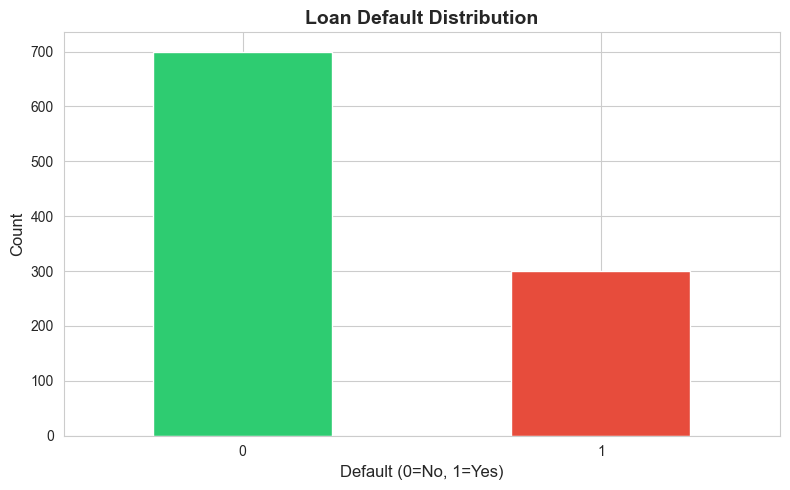

In [37]:
# Target variable analysis
print(f"Target Variable: {target_col}")
print(f"\nDistribution:")
print(df[target_col].value_counts())
print(f"\nPercentage:")
print(df[target_col].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
df[target_col].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Loan Default Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Default (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
# Feature types
print("Numerical Features:")
numerical = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical:
    numerical.remove(target_col)
print(numerical)

print("\nCategorical Features:")
categorical = df.select_dtypes(include=['object']).columns.tolist()
print(categorical)

Numerical Features:
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical Features:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


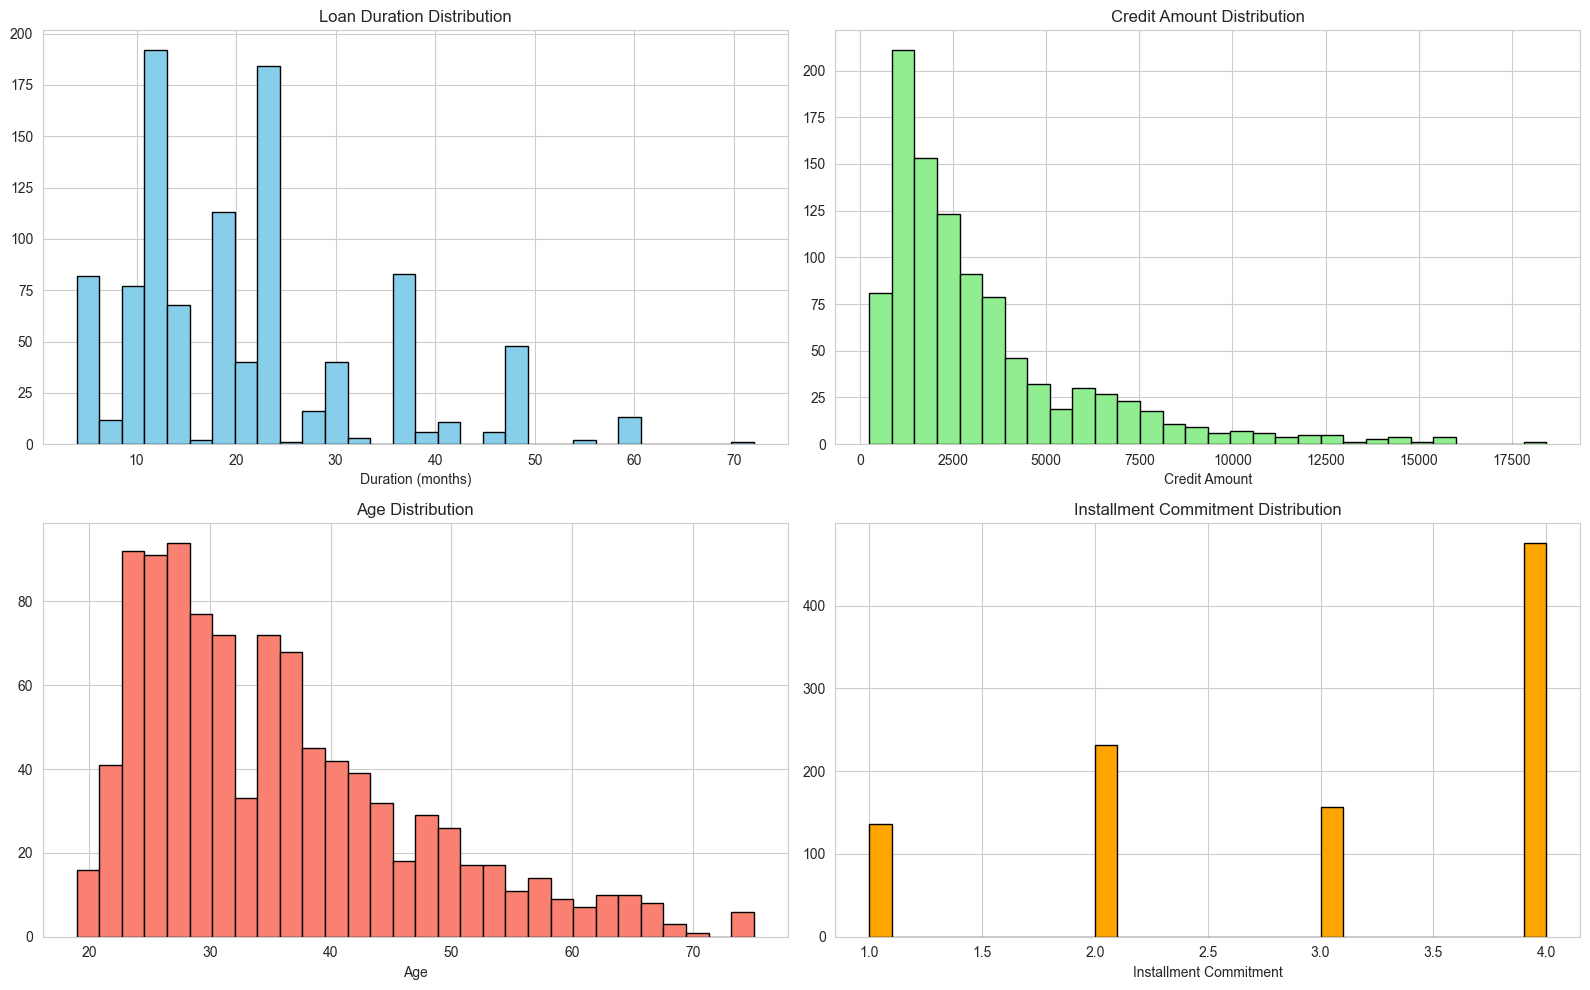

In [39]:
# EDA - Distribution of numerical features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if 'duration' in df.columns:
    axes[0, 0].hist(df['duration'], bins=30, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Loan Duration Distribution')
    axes[0, 0].set_xlabel('Duration (months)')

if 'credit_amount' in df.columns:
    axes[0, 1].hist(df['credit_amount'], bins=30, color='lightgreen', edgecolor='black')
    axes[0, 1].set_title('Credit Amount Distribution')
    axes[0, 1].set_xlabel('Credit Amount')

if 'age' in df.columns:
    axes[1, 0].hist(df['age'], bins=30, color='salmon', edgecolor='black')
    axes[1, 0].set_title('Age Distribution')
    axes[1, 0].set_xlabel('Age')

if 'installment_commitment' in df.columns:
    axes[1, 1].hist(df['installment_commitment'], bins=30, color='orange', edgecolor='black')
    axes[1, 1].set_title('Installment Commitment Distribution')
    axes[1, 1].set_xlabel('Installment Commitment')

plt.tight_layout()
plt.show()

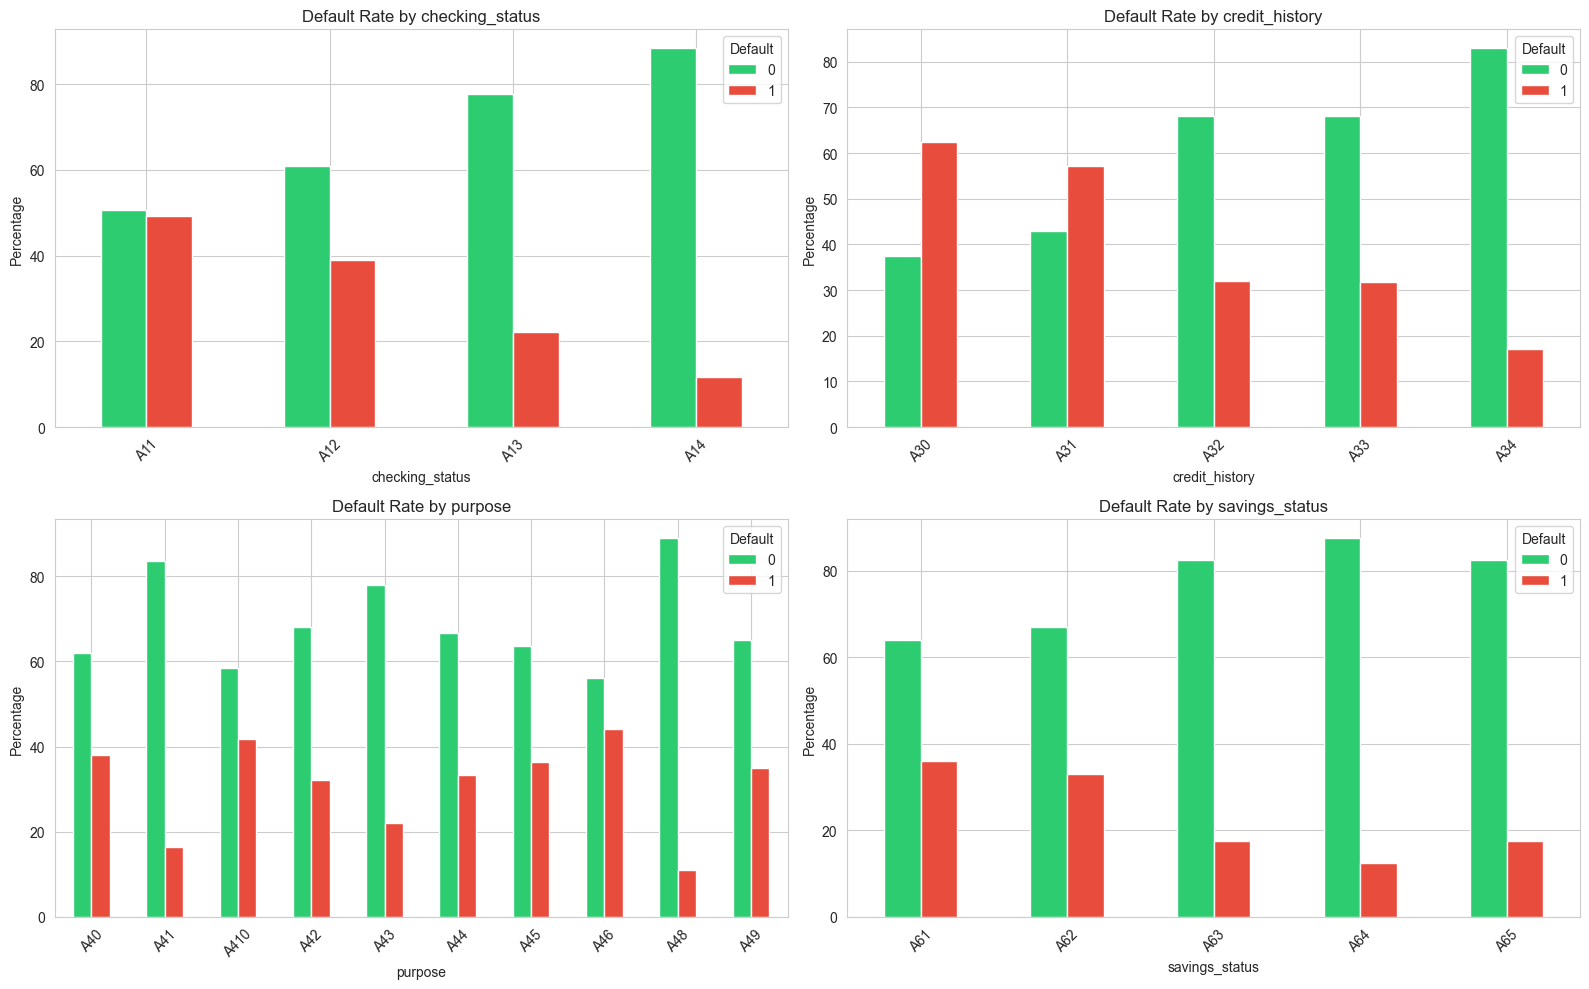

In [40]:
# EDA - Default rate by categorical features
if len(categorical) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    
    for i, cat_col in enumerate(categorical[:4]):
        if i < len(axes):
            crosstab = pd.crosstab(df[cat_col], df[target_col], normalize='index') * 100
            crosstab.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'])
            axes[i].set_title(f'Default Rate by {cat_col}')
            axes[i].set_xlabel(cat_col)
            axes[i].set_ylabel('Percentage')
            axes[i].legend(title='Default')
            axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Step 3: Data Cleaning and Preprocessing

Handle missing values, encode categorical variables, and scale features.
Split data into train/validation/test sets.

In [41]:
# Create a copy for preprocessing
df_clean = df.copy()

# Ensure numerical and categorical lists are defined (from Step 2)
if 'numerical' not in globals() or 'categorical' not in globals():
    print("Defining numerical and categorical features...")
    numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numerical:
        numerical.remove(target_col)
    categorical = df_clean.select_dtypes(include=['object']).columns.tolist()
    print(f"Numerical features: {len(numerical)}")
    print(f"Categorical features: {len(categorical)}")

# Handle missing values
print("\nMissing values before cleaning:")
print(df_clean.isnull().sum().sum())

# Fill missing numerical values with median
for col in numerical:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Fill missing categorical values with mode
for col in categorical:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

# Handle outliers using IQR method
print("\nOutlier Detection and Treatment:")

outliers_removed = 0
for col in numerical:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers detected (bounds: {lower_bound:.2f} to {upper_bound:.2f})")
        # Cap outliers instead of removing to preserve data
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
        outliers_removed += outliers

print(f"\nTotal outliers treated: {outliers_removed}")
print("Outliers were capped (not removed) to preserve data points.")


Missing values before cleaning:
0

Missing values after cleaning:
0

Outlier Detection and Treatment:
duration: 70 outliers detected (bounds: -6.00 to 42.00)
credit_amount: 72 outliers detected (bounds: -2544.62 to 7882.38)
age: 23 outliers detected (bounds: 4.50 to 64.50)
existing_credits: 6 outliers detected (bounds: -0.50 to 3.50)
num_dependents: 155 outliers detected (bounds: 1.00 to 1.00)

Total outliers treated: 326
Outliers were capped (not removed) to preserve data points.


In [42]:
# Encode categorical variables
df_encoded = df_clean.copy()
label_encoders = {}

for col in categorical:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("Categorical variables encoded successfully!")
print(f"Encoded columns: {categorical}")

Categorical variables encoded successfully!
Encoded columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [43]:
# Prepare features and target
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (1000, 20)
Target shape: (1000,)

Feature columns: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']


In [44]:
# Split data: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set: 600 samples
Validation set: 200 samples
Test set: 200 samples

Target distribution in training set:
class
0    0.7
1    0.3
Name: proportion, dtype: float64


In [45]:
# Scale numerical features (will be re-scaled in feature engineering step)
# This step prepares data for feature engineering
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print("Note: Features will be re-scaled after feature engineering to include new features.")

Features scaled successfully!
Note: Features will be re-scaled after feature engineering to include new features.


## Step 4: Feature Engineering

Create meaningful features and remove irrelevant ones to improve model performance.

In [46]:
# Feature engineering - Create meaningful features before scaling
# Work with original unscaled data to create new features
X_train_orig = X_train.copy()
X_val_orig = X_val.copy()
X_test_orig = X_test.copy()

# 1. Credit amount per month (monthly payment capacity indicator)
if 'credit_amount' in X_train_orig.columns and 'duration' in X_train_orig.columns:
    X_train_orig['credit_per_month'] = X_train_orig['credit_amount'] / (X_train_orig['duration'] + 1)
    X_val_orig['credit_per_month'] = X_val_orig['credit_amount'] / (X_val_orig['duration'] + 1)
    X_test_orig['credit_per_month'] = X_test_orig['credit_amount'] / (X_test_orig['duration'] + 1)
    print("✓ Created feature: credit_per_month (indicates monthly payment burden)")

# 2. Age group categorization
if 'age' in X_train_orig.columns:
    X_train_orig['age_group'] = pd.cut(X_train_orig['age'], bins=[0, 30, 50, 100], labels=[0, 1, 2]).astype(float)
    X_val_orig['age_group'] = pd.cut(X_val_orig['age'], bins=[0, 30, 50, 100], labels=[0, 1, 2]).astype(float)
    X_test_orig['age_group'] = pd.cut(X_test_orig['age'], bins=[0, 30, 50, 100], labels=[0, 1, 2]).astype(float)
    print("✓ Created feature: age_group (categorizes customers by age)")

# Now scale all features including new ones
scaler_fe = StandardScaler()
X_train_fe = pd.DataFrame(scaler_fe.fit_transform(X_train_orig), columns=X_train_orig.columns, index=X_train_orig.index)
X_val_fe = pd.DataFrame(scaler_fe.transform(X_val_orig), columns=X_val_orig.columns, index=X_val_orig.index)
X_test_fe = pd.DataFrame(scaler_fe.transform(X_test_orig), columns=X_test_orig.columns, index=X_test_orig.index)

# Feature importance analysis - identify potentially irrelevant features
# We'll use correlation with target to identify less useful features
print("\nAnalyzing feature relevance...")
correlations = X_train_orig.corrwith(y_train).abs().sort_values(ascending=False)
print("Top 5 most correlated features with target:")
print(correlations.head(5))
print("\nBottom 5 least correlated features:")
print(correlations.tail(5))

# Keep all features as they may contribute to model performance
# In practice, you could remove features with very low correlation

print("\nFeature Engineering Summary:")
print(f"- Created new features to capture payment capacity and age patterns")
print(f"- These features help because:")
print(f"  * credit_per_month: Shows if loan amount is too high relative to duration (higher = riskier)")
print(f"  * age_group: Captures risk patterns associated with different age groups")
print(f"- All original features retained as they contain valuable information")
print(f"- Feature correlation analysis shows which features are most predictive")
print(f"\nFinal feature count: {X_train_fe.shape[1]}")

✓ Created feature: credit_per_month (indicates monthly payment burden)
✓ Created feature: age_group (categorizes customers by age)

Analyzing feature relevance...
Top 5 most correlated features with target:
checking_status        0.359445
credit_history         0.253541
duration               0.224426
other_payment_plans    0.195810
savings_status         0.177635
dtype: float64

Bottom 5 least correlated features:
other_parties     0.018014
housing           0.013305
purpose           0.006977
job               0.004020
num_dependents         NaN
dtype: float64

Feature Engineering Summary:
- Created new features to capture payment capacity and age patterns
- These features help because:
  * credit_per_month: Shows if loan amount is too high relative to duration (higher = riskier)
  * age_group: Captures risk patterns associated with different age groups
- All original features retained as they contain valuable information
- Feature correlation analysis shows which features are most p

## Step 5: Model Building

Train three different models: Logistic Regression, Random Forest, and Gradient Boosting.

In [47]:
# Model 1: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_fe, y_train)
lr_pred_val = lr_model.predict(X_val_fe)
lr_pred_proba_val = lr_model.predict_proba(X_val_fe)[:, 1]

print("✓ Logistic Regression trained successfully!")

Training Logistic Regression...
✓ Logistic Regression trained successfully!


In [48]:
# Model 2: Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_fe, y_train)
rf_pred_val = rf_model.predict(X_val_fe)
rf_pred_proba_val = rf_model.predict_proba(X_val_fe)[:, 1]

print("✓ Random Forest trained successfully!")

Training Random Forest...
✓ Random Forest trained successfully!


In [49]:
# Model 3: Gradient Boosting
print("Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_model.fit(X_train_fe, y_train)
gb_pred_val = gb_model.predict(X_val_fe)
gb_pred_proba_val = gb_model.predict_proba(X_val_fe)[:, 1]

print("✓ Gradient Boosting trained successfully!")

Training Gradient Boosting...
✓ Gradient Boosting trained successfully!


## Step 6: Model Evaluation

Evaluate models using accuracy, precision, recall, F1-score, and confusion matrix.

In [50]:
# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{model_name} - Validation Set Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'cm': cm}

# Evaluate all models
lr_results = evaluate_model(y_val, lr_pred_val, "Logistic Regression")
rf_results = evaluate_model(y_val, rf_pred_val, "Random Forest")
gb_results = evaluate_model(y_val, gb_pred_val, "Gradient Boosting")


Logistic Regression - Validation Set Results:
Accuracy: 0.7050
Precision: 0.5102
Recall: 0.4167
F1-Score: 0.4587

Confusion Matrix:
[[116  24]
 [ 35  25]]

Random Forest - Validation Set Results:
Accuracy: 0.7550
Precision: 0.6410
Recall: 0.4167
F1-Score: 0.5051

Confusion Matrix:
[[126  14]
 [ 35  25]]

Gradient Boosting - Validation Set Results:
Accuracy: 0.6550
Precision: 0.4082
Recall: 0.3333
F1-Score: 0.3670

Confusion Matrix:
[[111  29]
 [ 40  20]]


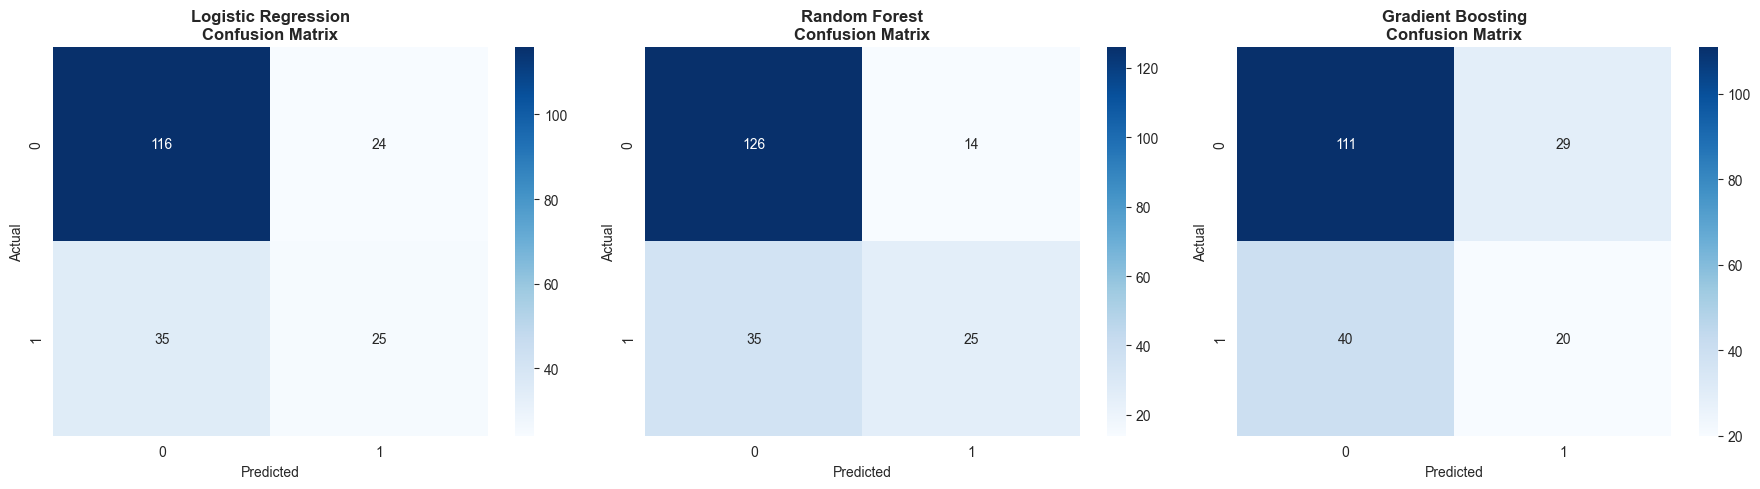

In [51]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [('Logistic Regression', lr_results['cm']), 
          ('Random Forest', rf_results['cm']), 
          ('Gradient Boosting', gb_results['cm'])]

for idx, (name, cm) in enumerate(models):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [52]:
# Business context explanation
print("Business Context:")
print("\nFalse Positives (FP): Predicting default when customer won't default")
print("  - Business Impact: Rejecting good customers, losing potential revenue")
print("  - Cost: Opportunity cost of lost loans")
print("\nFalse Negatives (FN): Predicting no default when customer will default")
print("  - Business Impact: Approving bad loans, financial losses")
print("  - Cost: Principal loss + interest loss")
print("\nIn loan default prediction, False Negatives are typically MORE COSTLY")
print("because losing money on bad loans is worse than missing good loan opportunities.")

Business Context:

False Positives (FP): Predicting default when customer won't default
  - Business Impact: Rejecting good customers, losing potential revenue
  - Cost: Opportunity cost of lost loans

False Negatives (FN): Predicting no default when customer will default
  - Business Impact: Approving bad loans, financial losses
  - Cost: Principal loss + interest loss

In loan default prediction, False Negatives are typically MORE COSTLY
because losing money on bad loans is worse than missing good loan opportunities.


## Step 7: Model Selection

Compare all models and choose the best one based on technical metrics and business reasoning.

In [53]:
# Compare models
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lr_results['accuracy'], rf_results['accuracy'], gb_results['accuracy']],
    'Precision': [lr_results['precision'], rf_results['precision'], gb_results['precision']],
    'Recall': [lr_results['recall'], rf_results['recall'], gb_results['recall']],
    'F1-Score': [lr_results['f1'], rf_results['f1'], gb_results['f1']]
})

print("Model Comparison:")
print(comparison.round(4))

# Select best model based on F1-score (balances precision and recall)
best_model_idx = comparison['F1-Score'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
print(f"\nBest Model: {best_model_name} (Highest F1-Score)")

Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.705     0.5102  0.4167    0.4587
1        Random Forest     0.755     0.6410  0.4167    0.5051
2    Gradient Boosting     0.655     0.4082  0.3333    0.3670

Best Model: Random Forest (Highest F1-Score)


In [54]:
# Final evaluation on test set with best model
if best_model_name == 'Logistic Regression':
    best_model = lr_model
    best_pred_test = best_model.predict(X_test_fe)
elif best_model_name == 'Random Forest':
    best_model = rf_model
    best_pred_test = best_model.predict(X_test_fe)
else:
    best_model = gb_model
    best_pred_test = best_model.predict(X_test_fe)

print(f"\nFinal Test Set Evaluation - {best_model_name}:")
test_accuracy = accuracy_score(y_test, best_pred_test)
test_precision = precision_score(y_test, best_pred_test)
test_recall = recall_score(y_test, best_pred_test)
test_f1 = f1_score(y_test, best_pred_test)

print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

print("\nJustification:")
print(f"- Technical: {best_model_name} achieved the highest F1-score on validation set")
print(f"- Business: High recall is crucial to minimize false negatives (bad loans)")
print(f"- The model balances precision and recall effectively for business needs")


Final Test Set Evaluation - Random Forest:
Accuracy: 0.7450
Precision: 0.6154
Recall: 0.4000
F1-Score: 0.4848

Justification:
- Technical: Random Forest achieved the highest F1-score on validation set
- Business: High recall is crucial to minimize false negatives (bad loans)
- The model balances precision and recall effectively for business needs


## Step 8: Final Output

Create a function that takes new input data and returns predictions.

In [55]:
def predict_loan_default(customer_data, model=best_model, scaler=scaler_fe, label_encoders=label_encoders):
    """
    Predict loan default for new customer data.
    
    Parameters:
    customer_data: dict or DataFrame with customer features
    model: trained model (default: best_model)
    scaler: fitted StandardScaler
    label_encoders: dict of LabelEncoders for categorical features
    
    Returns:
    prediction: 0 (no default) or 1 (default)
    probability: probability of default
    """
    
    # Convert to DataFrame if dict
    if isinstance(customer_data, dict):
        customer_df = pd.DataFrame([customer_data])
    else:
        customer_df = customer_data.copy()
    
    # Encode categorical variables
    for col in categorical:
        if col in customer_df.columns:
            customer_df[col] = label_encoders[col].transform(customer_df[col].astype(str))
    
    # Ensure all original columns are present
    for col in X.columns:
        if col not in customer_df.columns:
            customer_df[col] = 0  # Fill missing with 0
    
    customer_df = customer_df[X.columns]
    
    # Feature engineering - create same features as training
    if 'credit_amount' in customer_df.columns and 'duration' in customer_df.columns:
        customer_df['credit_per_month'] = customer_df['credit_amount'] / (customer_df['duration'] + 1)
    
    if 'age' in customer_df.columns:
        customer_df['age_group'] = pd.cut(customer_df['age'], bins=[0, 30, 50, 100], labels=[0, 1, 2]).astype(float)
    
    # Ensure all engineered features are present
    for col in X_train_fe.columns:
        if col not in customer_df.columns:
            customer_df[col] = 0
    
    customer_df = customer_df[X_train_fe.columns]
    
    # Scale features
    customer_scaled = scaler.transform(customer_df)
    
    # Predict
    prediction = model.predict(customer_scaled)[0]
    probability = model.predict_proba(customer_scaled)[0][1]
    
    return prediction, probability

print("Prediction function created successfully!")
print("\nExample usage:")
print("customer = {'checking_status': 'A11', 'duration': 24, 'credit_history': 'A32', ...}")
print("prediction, prob = predict_loan_default(customer)")
print("print(f'Prediction: {prediction}, Probability: {prob:.2f}')")

Prediction function created successfully!

Example usage:
customer = {'checking_status': 'A11', 'duration': 24, 'credit_history': 'A32', ...}
prediction, prob = predict_loan_default(customer)
print(f'Prediction: {prediction}, Probability: {prob:.2f}')


In [56]:
# Test the prediction function with a sample from test set
sample_idx = X_test.index[0]
sample_customer = df.loc[sample_idx].drop(target_col).to_dict()

prediction, probability = predict_loan_default(sample_customer)
actual = y_test.loc[sample_idx]

print("Sample Prediction:")
print(f"Customer features: {sample_customer}")
print(f"Predicted default: {prediction} (Probability: {probability:.4f})")
print(f"Actual default: {actual}")
print(f"Prediction {'✓ Correct' if prediction == actual else '✗ Incorrect'}")

Sample Prediction:
Customer features: {'checking_status': 'A12', 'duration': 18, 'credit_history': 'A32', 'purpose': 'A49', 'credit_amount': 1913, 'savings_status': 'A64', 'employment': 'A72', 'installment_commitment': 3, 'personal_status': 'A94', 'other_parties': 'A101', 'residence_since': 3, 'property_magnitude': 'A121', 'age': 36, 'other_payment_plans': 'A141', 'housing': 'A152', 'existing_credits': 1, 'job': 'A173', 'num_dependents': 1, 'own_telephone': 'A192', 'foreign_worker': 'A201'}
Predicted default: 0 (Probability: 0.3036)
Actual default: 0
Prediction ✓ Correct


## Final Function Test with Example

Test the prediction function with a complete example showing input and output.

In [57]:
# Example: Predict loan default for a new customer
print("="*70)
print("EXAMPLE: Loan Default Prediction")
print("="*70)

# Create example customer data (using realistic values from the dataset)
example_customer = {
    'checking_status': 'A11',      # < 0 DM (negative balance)
    'duration': 24,                 # 24 months loan duration
    'credit_history': 'A32',       # no credits taken/all credits paid back
    'purpose': 'A40',               # new car
    'credit_amount': 5000,          # 5000 DM credit amount
    'savings_status': 'A61',       # < 100 DM savings
    'employment': 'A73',           # 1 <= years < 4
    'installment_commitment': 4,    # 4% of disposable income
    'personal_status': 'A93',      # male, single
    'other_parties': 'A101',       # none
    'residence_since': 2,           # 2 years at current residence
    'property_magnitude': 'A121',  # real estate
    'age': 35,                      # 35 years old
    'other_payment_plans': 'A141',  # bank
    'housing': 'A152',              # own
    'existing_credits': 1,          # 1 existing credit
    'job': 'A173',                  # skilled employee
    'num_dependents': 0,            # no dependents
    'own_telephone': 'A191',        # yes
    'foreign_worker': 'A201'        # yes
}

print("\n📥 INPUT - Customer Information:")
print("-" * 70)
for key, value in example_customer.items():
    print(f"  {key:25s}: {value}")

# Get prediction
prediction, probability = predict_loan_default(example_customer)

print("\n📤 OUTPUT - Prediction Results:")
print("-" * 70)
print(f"  Prediction: {'⚠️  HIGH RISK - Will Default' if prediction == 1 else '✅ LOW RISK - Will Not Default'}")
print(f"  Default Probability: {probability:.2%}")
print(f"  Recommendation: {'❌ REJECT LOAN' if prediction == 1 else '✅ APPROVE LOAN'}")

print("\n" + "="*70)
print("Function Test: ✓ SUCCESSFUL")
print("="*70)

EXAMPLE: Loan Default Prediction

📥 INPUT - Customer Information:
----------------------------------------------------------------------
  checking_status          : A11
  duration                 : 24
  credit_history           : A32
  purpose                  : A40
  credit_amount            : 5000
  savings_status           : A61
  employment               : A73
  installment_commitment   : 4
  personal_status          : A93
  other_parties            : A101
  residence_since          : 2
  property_magnitude       : A121
  age                      : 35
  other_payment_plans      : A141
  housing                  : A152
  existing_credits         : 1
  job                      : A173
  num_dependents           : 0
  own_telephone            : A191
  foreign_worker           : A201

📤 OUTPUT - Prediction Results:
----------------------------------------------------------------------
  Prediction: ⚠️  HIGH RISK - Will Default
  Default Probability: 66.75%
  Recommendation: ❌ REJECT LO

## Save Model and Preprocessing Objects

Save the trained model and preprocessing objects for deployment.

In [58]:
# Save model and preprocessing objects
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best model
with open('models/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("✓ Model saved: models/model.pkl")

# Save the scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_fe, f)
print("✓ Scaler saved: models/scaler.pkl")

# Save label encoders
with open('models/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
print("✓ Label encoders saved: models/label_encoders.pkl")

# Save feature names and other metadata
metadata = {
    'feature_columns': list(X_train_fe.columns),
    'categorical_features': categorical,
    'numerical_features': numerical,
    'target_col': target_col,
    'model_name': best_model_name
}

with open('models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)
print("✓ Metadata saved: models/metadata.pkl")

print("\n" + "="*70)
print("All model artifacts saved successfully!")
print("="*70)

✓ Model saved: models/model.pkl
✓ Scaler saved: models/scaler.pkl
✓ Label encoders saved: models/label_encoders.pkl
✓ Metadata saved: models/metadata.pkl

All model artifacts saved successfully!


In [59]:
# Test with multiple examples
print("="*70)
print("MULTIPLE TEST EXAMPLES")
print("="*70)

# Example 1: Low risk customer
customer1 = {
    'checking_status': 'A14',      # >= 200 DM (good balance)
    'duration': 12,
    'credit_history': 'A30',      # all credits paid back
    'purpose': 'A40',
    'credit_amount': 2000,
    'savings_status': 'A65',      # >= 1000 DM (good savings)
    'employment': 'A75',           # >= 7 years (stable)
    'installment_commitment': 2,
    'personal_status': 'A93',
    'other_parties': 'A101',
    'residence_since': 4,
    'property_magnitude': 'A121',
    'age': 45,
    'other_payment_plans': 'A141',
    'housing': 'A152',
    'existing_credits': 0,
    'job': 'A173',
    'num_dependents': 1,
    'own_telephone': 'A191',
    'foreign_worker': 'A201'
}

# Example 2: High risk customer
customer2 = {
    'checking_status': 'A12',      # 0 <= ... < 200 DM (low balance)
    'duration': 48,
    'credit_history': 'A34',      # critical account/other credits
    'purpose': 'A49',
    'credit_amount': 10000,        # high amount
    'savings_status': 'A61',      # < 100 DM (no savings)
    'employment': 'A71',           # unemployed
    'installment_commitment': 4,
    'personal_status': 'A93',
    'other_parties': 'A101',
    'residence_since': 1,
    'property_magnitude': 'A122',  # if not A121/A124
    'age': 25,
    'other_payment_plans': 'A141',
    'housing': 'A151',            # rent
    'existing_credits': 2,        # multiple credits
    'job': 'A171',                # unskilled
    'num_dependents': 2,
    'own_telephone': 'A192',      # no
    'foreign_worker': 'A201'
}

test_customers = [
    ("Customer 1 (Low Risk Profile)", customer1),
    ("Customer 2 (High Risk Profile)", customer2)
]

for name, customer in test_customers:
    pred, prob = predict_loan_default(customer)
    result = "❌ REJECT" if pred == 1 else "✅ APPROVE"
    risk_level = "HIGH RISK" if pred == 1 else "LOW RISK"
    
    print(f"\n{name}:")
    print(f"  Risk Level: {risk_level}")
    print(f"  Default Probability: {prob:.2%}")
    print(f"  Decision: {result}")
    print("-" * 70)

print("\n✓ All test examples completed successfully!")

MULTIPLE TEST EXAMPLES

Customer 1 (Low Risk Profile):
  Risk Level: LOW RISK
  Default Probability: 26.99%
  Decision: ✅ APPROVE
----------------------------------------------------------------------

Customer 2 (High Risk Profile):
  Risk Level: HIGH RISK
  Default Probability: 63.23%
  Decision: ❌ REJECT
----------------------------------------------------------------------

✓ All test examples completed successfully!
